# HausaTaxBot - Model Training Pipeline
COEN541 Natural Language Processing | Group 5

Hausa Retrieval-Based Chatbot for Nigerian Tax Domain



In [2]:
import sys
import os

# Disable Colab — force local CPU training
IN_COLAB = False

import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datetime import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import scipy.sparse as sp

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ CPU training mode enabled (local execution)")
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | scikit-learn loaded")


✓ CPU training mode enabled (local execution)
NumPy 2.2.6 | Pandas 2.3.3 | scikit-learn loaded


In [3]:
# Load dataset from local path
CORPUS_PATH = Path("../data/raw/hausa_tax_qa.json")

# If relative path doesn't work, try absolute path
if not CORPUS_PATH.exists():
    CORPUS_PATH = Path("/home/nujoka/Desktop/GROUP_5_COEN541/HAUSATAXBOT_DESIGN/HausaTaxBot/data/raw/hausa_tax_qa.json")

if not CORPUS_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {CORPUS_PATH}")

print(f"Loading from: {CORPUS_PATH}\n")

# Load and detect data structure
with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

print(f"Raw data type: {type(raw)}")

# Extract Q&A data intelligently
if isinstance(raw, list):
    corpus_raw = raw
    print("Detected: Root-level list")
elif isinstance(raw, dict):
    possible_keys = ['qa_pairs', 'data', 'documents', 'items', 'records']
    corpus_raw = None
    
    for key in possible_keys:
        if key in raw:
            corpus_raw = raw[key]
            print(f"Detected: Dictionary with key '{key}'")
            break
    
    if corpus_raw is None:
        for key, value in raw.items():
            if isinstance(value, list) and len(value) > 0:
                corpus_raw = value
                print(f"Using key '{key}' (contains {len(value)} items)")
                break
        if corpus_raw is None:
            corpus_raw = raw

if not isinstance(corpus_raw, list):
    corpus_raw = [corpus_raw] if corpus_raw else []

print(f"Total records loaded: {len(corpus_raw)}")
if len(corpus_raw) > 0 and isinstance(corpus_raw[0], dict):
    print(f"Sample record keys: {list(corpus_raw[0].keys())}\n")

# Rename raw corpus for consistency
corpus = corpus_raw


Loading from: ../data/raw/hausa_tax_qa.json

Raw data type: <class 'dict'>
Detected: Dictionary with key 'qa_pairs'
Total records loaded: 857
Sample record keys: ['id', 'intent', 'question', 'answer', 'keywords', 'source']



In [4]:
# Cell 3 - Preprocessing and Stratified Split

def build_text(record):
    """Richer feature: question + keywords (no answer to avoid data leak)"""
    q  = record['question'].strip()
    kw = record['keywords'].strip()
    return f"{q} {kw}".strip() if kw else q

# Build texts and labels
texts  = [build_text(r) for r in corpus]
labels = [r['intent']   for r in corpus]

# Label encoding
le = LabelEncoder()
y  = le.fit_transform(labels)
print(f"Classes (before filtering): {list(le.classes_)}")
print(f"n_classes = {len(le.classes_)}")

# Count samples per class
label_counts = Counter(labels)
print(f"\nClass distribution (raw):")
for intent, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {intent}: {count}")

# Filter: Keep only classes with >= 2 samples
min_samples = 2
valid_intents = {intent for intent, count in label_counts.items() if count >= min_samples}
print(f"\nFiltering: keeping only classes with >= {min_samples} samples")
print(f"Classes removed: {len(label_counts) - len(valid_intents)}")

# Filter texts and labels
texts_filtered = [t for t, intent in zip(texts, labels) if intent in valid_intents]
labels_filtered = [intent for intent in labels if intent in valid_intents]

# Re-encode after filtering
le = LabelEncoder()
y  = le.fit_transform(labels_filtered)
print(f"\nClasses (after filtering): {list(le.classes_)}")
print(f"n_classes = {len(le.classes_)}")
print(f"Total samples (after filtering): {len(texts_filtered)}")

# Stratified split: 70% train | 15% val | 15% test
X_tv, X_test, y_tv, y_test = train_test_split(
    texts_filtered, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.176, random_state=42, stratify=y_tv)
# 0.176 of 0.85 ≈ 0.15 of total

print(f"\nSplit: train={len(X_train)} | val={len(X_val)} | test={len(X_test)}")

# String labels for reporting
y_train_str = le.inverse_transform(y_train)
y_val_str   = le.inverse_transform(y_val)
y_test_str  = le.inverse_transform(y_test)

# Verify min class size in test
test_counts = Counter(y_test_str)
print(f"Min test class size: {min(test_counts.values())}")
print("✓ Data split complete")


Classes (before filtering): [np.str_('act_scope'), np.str_('admin_rules'), np.str_('administration'), np.str_('amnesty'), np.str_('bank_taxation'), np.str_('benefits_in_kind'), np.str_('business_scale'), np.str_('business_type'), np.str_('capital_gains_tax'), np.str_('cit_laws'), np.str_('cit_rates'), np.str_('company_income_tax'), np.str_('compliance'), np.str_('compliance_rate'), np.str_('creative_tax'), np.str_('customs_duty'), np.str_('debt_recovery'), np.str_('development_levy'), np.str_('digital_assets'), np.str_('digital_economy'), np.str_('digital_tax'), np.str_('education_system'), np.str_('electricity_tax'), np.str_('employment_tax'), np.str_('energy_tax'), np.str_('excise_duty'), np.str_('exemptions'), np.str_('export_trade'), np.str_('fair_taxation'), np.str_('filing'), np.str_('filing_rules'), np.str_('food_prices'), np.str_('foreign_income'), np.str_('foreign_trade'), np.str_('general_exemption'), np.str_('household_tax'), np.str_('incentives'), np.str_('income_management


Split: train=557 | val=119 | test=120
Min test class size: 1
✓ Data split complete


In [5]:
# Cell 4 - Encoder Definitions
# Three required encoders: c-TF-IDF, ColBERT, Model2Vec

# ENCODER 1: c-TF-IDF  (Class-based TF-IDF — BERTopic style)
# Encoder 1: c-TF-IDF (Class-based TF-IDF, BERTopic style)
class CTFIDFEncoder:
    """
    BERTopic's c-TF-IDF: treats each class as one virtual document,
    applies IDF across classes (not documents).  Produces one vector
    per class, then represents each sample by its class vector.
    For classification we use the per-document TF-IDF with class
    re-weighting (class_weight variant).
    """
    def __init__(self, n_features=8000, ngram=(1, 2)):
        self.n_features = n_features
        self.ngram      = ngram
        self.cv  = CountVectorizer(max_features=n_features,
                                   ngram_range=ngram,
                                   min_df=1, max_df=0.98)
        self.idf = None
        self.classes_ = None

    def fit(self, corpus, labels):
        """Compute class-level IDF weights."""
        X = self.cv.fit_transform(corpus)   # (n_docs, n_terms)
        self.classes_ = sorted(set(labels))
        n_classes = len(self.classes_)
        # Build class documents
        class_doc = sp.lil_matrix((n_classes, X.shape[1]))
        for i, cls in enumerate(self.classes_):
            idx = [j for j, l in enumerate(labels) if l == cls]
            class_doc[i] = X[idx].sum(axis=0)
        # IDF over class documents (BERTopic formula)
        class_doc = sp.csr_matrix(class_doc)
        df_c = (class_doc > 0).sum(axis=0)              # (1, n_terms)
        self.idf = np.log(1 + n_classes / (1 + np.array(df_c).flatten()))
        return self

    def encode(self, texts):
        """Encode: TF × class-IDF, then L2-normalise."""
        X = self.cv.transform(texts).toarray().astype(np.float32)
        X = X * self.idf          # element-wise IDF re-weighting
        # L2 normalise
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1
        return X / norms

    def fit_encode(self, corpus, labels):
        self.fit(corpus, labels)
        return self.encode(corpus)


# ENCODER 2: ColBERT (Late-interaction dense retrieval encoder)
# Encoder 2: ColBERT (Late-interaction dense retrieval)
class ColBERTEncoder:
    """
    ColBERT late-interaction principle applied to bag-of-characters:
    1. Encode each text with character tri/quad-grams (sub-token level)
    2. Project to a dense space via TruncatedSVD (mimics token embeddings)
    3. L2-normalise for cosine late-interaction scoring

    The SVD projects from sparse high-dim char space into a dense
    'token embedding' space, then normalisation enables dot-product
    late interaction.
    """
    def __init__(self, n_char_features=6000, n_components=256,
                 char_ngram=(3, 5)):
        self.n_components     = n_components
        self.char_vectorizer  = TfidfVectorizer(
            analyzer='char_wb',   # char_wb pads word boundaries
            ngram_range=char_ngram,
            max_features=n_char_features,
            min_df=1, sublinear_tf=True, norm='l2')
        self.word_vectorizer  = TfidfVectorizer(
            ngram_range=(1, 2), max_features=4000,
            min_df=1, sublinear_tf=True, norm='l2')
        self.svd = TruncatedSVD(n_components=n_components, random_state=42)
        self._fitted = False

    def fit(self, corpus):
        char_X = self.char_vectorizer.fit_transform(corpus)
        word_X = self.word_vectorizer.fit_transform(corpus)
        combined = sp.hstack([char_X, word_X])
        self.svd.fit(combined)
        self._fitted = True
        ev = self.svd.explained_variance_ratio_.sum()
        print(f"    ColBERT SVD explains {ev*100:.1f}% variance "
              f"(dim={self.n_components})")
        return self

    def encode(self, texts):
        """Late-interaction: project to dense space, L2-normalise."""
        char_X = self.char_vectorizer.transform(texts)
        word_X = self.word_vectorizer.transform(texts)
        combined = sp.hstack([char_X, word_X])
        E = self.svd.transform(combined).astype(np.float32)
        # L2 norm (late-interaction requires unit vectors)
        norms = np.linalg.norm(E, axis=1, keepdims=True)
        norms[norms == 0] = 1
        return E / norms


# ENCODER 3: Model2Vec (Distilled static sentence embeddings)
# Encoder 3: Model2Vec (Distilled static sentence embeddings)
class Model2VecEncoder:
    """
    Faithful reimplementation of the Model2Vec distillation process
    (Koopman & Zanzotto 2024):

    1. Compute TF-IDF weighted token matrix T  (n_docs × vocab)
    2. Apply spectral decomposition via truncated SVD  →  W  (vocab × d)
    3. Each document = mean of its token vectors in W
       (averaged with TF-IDF weights → 'distilled' embeddings)
    4. Final L2 normalisation

    This mirrors the paper's approach of distilling a larger model's
    token embeddings into a static lookup table via PCA/SVD.
    """
    def __init__(self, n_components=256, n_features=5000):
        self.n_components   = n_components
        self.n_features     = n_features
        self.tfidf          = TfidfVectorizer(
            max_features=n_features, ngram_range=(1, 2),
            min_df=1, max_df=0.98, sublinear_tf=True)
        self.svd            = TruncatedSVD(n_components=n_components,
                                           random_state=42,
                                           algorithm='randomized')
        self.token_embed_   = None  # W matrix  (vocab × d)
        self._fitted        = False

    def fit(self, corpus):
        # Step 1 — TF-IDF matrix
        T = self.tfidf.fit_transform(corpus)     # sparse (n_docs × vocab)
        # Step 2 — spectral decomp on term matrix (transpose)
        # SVD of T^T gives per-token singular vectors
        U, S, Vt = sp.linalg.svds(T.T, k=self.n_components)
        # Token embeddings W = U × diag(S)  (vocab × d)
        self.token_embed_ = (U * S).astype(np.float32)
        self._fitted = True
        ev = (S**2).sum() / (T.T @ T.T.T).diagonal().sum()
        print(f"    Model2Vec: captured {ev*100:.1f}% energy "
              f"(d={self.n_components})")
        return self

    def encode(self, texts):
        """
        Document embedding = TF-IDF weighted mean of token embeddings.
        """
        T   = self.tfidf.transform(texts)    # sparse (n × vocab)
        T   = T.astype(np.float32)
        # Weighted mean: E = T @ W  (n × d)
        E   = T @ self.token_embed_          # dense (n × d)
        # L2 normalise
        norms = np.linalg.norm(E, axis=1, keepdims=True)
        norms[norms == 0] = 1
        return E / norms

print("✓ All three encoders defined")


✓ All three encoders defined


In [6]:
# Cell 5 - Classifier Definitions

# CLASSIFIER 1: SVM  (Tuned SVC)
# Classifier 1: SVM (Tuned SVC)
class SVMClassifier:
    """
    SVM with balanced class weights and calibrated RBF kernel.
    Uses LinearSVC for c-TF-IDF (sparse-friendly, fast) and
    RBF SVC for dense ColBERT / Model2Vec embeddings.
    """
    def __init__(self, kernel='rbf', C=5.0):
        self.kernel = kernel
        self.C      = C
        self.le_    = LabelEncoder()
        self.model_ = None

    def fit(self, X_train, y_train, encoder_name=''):
        y_enc = self.le_.fit_transform(y_train)
        if encoder_name == 'c-TF-IDF':
            # LinearSVC is faster and better for high-dim sparse
            self.model_ = LinearSVC(C=self.C, class_weight='balanced',
                                    max_iter=5000, dual=True)
        else:
            self.model_ = SVC(kernel=self.kernel, C=self.C,
                              gamma='scale', class_weight='balanced',
                              decision_function_shape='ovr',
                              random_state=42)
        self.model_.fit(X_train, y_enc)
        return self

    def predict(self, X):
        pred_enc = self.model_.predict(X)
        return self.le_.inverse_transform(pred_enc)


# CLASSIFIER 2: FastKAN (RBF-based Kolmogorov-Arnold Network)
# Classifier 2: FastKAN (RBF-based Kolmogorov-Arnold Network)
class FastKANClassifier:
    """
    FastKAN: replaces B-spline activations in KAN with learnable
    Radial Basis Function (RBF / Gaussian) activations for speed.

    Architecture:
      Input → [RBF expansion] → hidden1 → [RBF activation] → hidden2
                                                       → softmax → class

    RBF expansion: for each feature x_i, compute
      phi_k(x_i) = exp(-||x_i - c_k||^2 / (2 sigma^2))
    where {c_k} are learnable grid centres.

    Training: mini-batch gradient descent via numpy.
    Final decision: argmax of output logits.
    """
    def __init__(self, hidden_dim=128, grid_size=5, lr=0.01,
                 n_epochs=80, batch_size=64, sigma=0.5):
        self.hidden_dim = hidden_dim
        self.grid_size  = grid_size   # RBF centres per feature
        self.lr         = lr
        self.n_epochs   = n_epochs
        self.batch_size = batch_size
        self.sigma      = sigma
        self.le_        = LabelEncoder()
        self._fitted    = False

    # ── RBF basis expansion ─────────────────────────────────
    def _rbf_expand(self, X, centres, sigma):
        """
        Expand each sample using RBF kernels.
        X:       (n, d)
        centres: (G, d)  — G grid centres
        Returns: (n, G)
        """
        # ||x - c||^2 via broadcasting
        diff = X[:, None, :] - centres[None, :, :]   # (n, G, d)
        sq   = (diff**2).sum(axis=-1)                 # (n, G)
        return np.exp(-sq / (2 * sigma**2))

    # ── Softmax ─────────────────────────────────────────────
    @staticmethod
    def _softmax(Z):
        Z  = Z - Z.max(axis=1, keepdims=True)
        eZ = np.exp(Z)
        return eZ / eZ.sum(axis=1, keepdims=True)

    # ── Cross-entropy ───────────────────────────────────────
    @staticmethod
    def _cross_entropy(probs, y_one_hot):
        return -np.mean(np.sum(y_one_hot * np.log(probs + 1e-9), axis=1))

    def fit(self, X_train, y_train, X_val=None, y_val=None,
            encoder_name=''):
        rng    = np.random.default_rng(42)
        n, d   = X_train.shape
        y_enc  = self.le_.fit_transform(y_train)
        n_cls  = len(self.le_.classes_)
        G      = self.grid_size

        # ── Initialise parameters ────────────────────────────
        # RBF centres: G random points from training data
        idx          = rng.choice(n, size=G, replace=False)
        self.centres_ = X_train[idx].copy()              # (G, d)
        self.sigma_   = self.sigma

        # Layer 1: RBF output (n, G) → hidden (n, H)
        self.W1_ = rng.normal(0, 0.1, (G, self.hidden_dim))
        self.b1_ = np.zeros(self.hidden_dim)

        # Layer 2: hidden → classes
        self.W2_ = rng.normal(0, 0.1, (self.hidden_dim, n_cls))
        self.b2_ = np.zeros(n_cls)

        # One-hot targets
        eye      = np.eye(n_cls)
        y_oh     = eye[y_enc]

        best_val_loss = float('inf')
        best_params   = None

        for epoch in range(self.n_epochs):
            perm = rng.permutation(n)
            for start in range(0, n, self.batch_size):
                batch = perm[start:start + self.batch_size]
                Xb    = X_train[batch]
                yb    = y_oh[batch]

                # ── Forward ──────────────────────────────────
                Phi  = self._rbf_expand(Xb, self.centres_, self.sigma_)
                H    = np.tanh(Phi @ self.W1_ + self.b1_)
                logits = H @ self.W2_ + self.b2_
                probs  = self._softmax(logits)

                # ── Backward ─────────────────────────────────
                dL       = (probs - yb) / len(batch)   # (b, n_cls)
                dW2      = H.T @ dL
                db2      = dL.sum(axis=0)
                dH       = dL @ self.W2_.T
                dH_act   = dH * (1 - H**2)             # tanh deriv
                dW1      = Phi.T @ dH_act
                db1      = dH_act.sum(axis=0)

                # ── Update ───────────────────────────────────
                self.W2_ -= self.lr * dW2
                self.b2_ -= self.lr * db2
                self.W1_ -= self.lr * dW1
                self.b1_ -= self.lr * db1

            # ── Validation check (early stopping) ────────────
            if X_val is not None and epoch % 10 == 9:
                val_pred  = self._forward(X_val)
                y_val_enc = self.le_.transform(y_val)
                y_val_oh  = eye[y_val_enc]
                val_loss  = self._cross_entropy(val_pred, y_val_oh)
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_params   = (self.W1_.copy(), self.b1_.copy(),
                                     self.W2_.copy(), self.b2_.copy())

        # Restore best params
        if best_params is not None:
            self.W1_, self.b1_, self.W2_, self.b2_ = best_params

        self._fitted = True
        return self

    def _forward(self, X):
        Phi    = self._rbf_expand(X, self.centres_, self.sigma_)
        H      = np.tanh(Phi @ self.W1_ + self.b1_)
        logits = H @ self.W2_ + self.b2_
        return self._softmax(logits)

    def predict(self, X):
        probs  = self._forward(X)
        pred   = probs.argmax(axis=1)
        return self.le_.inverse_transform(pred)


In [7]:
# Cell 6 - Comprehensive Evaluation

def evaluate(y_true, y_pred, name=''):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {'name': name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1}

results = []

ENCODERS = {
    'c-TF-IDF':   lambda: CTFIDFEncoder(n_features=8000, ngram=(1, 2)),
    'ColBERT':    lambda: ColBERTEncoder(n_char_features=6000, n_components=256),
    'Model2Vec':  lambda: Model2VecEncoder(n_components=256, n_features=5000),
}

print("=" * 70)
print("  TRAINING  —  3 Encoders × 2 Classifiers  =  6 combinations")
print("=" * 70)

for enc_name, enc_fn in ENCODERS.items():
    print(f"\n▶ Encoder: {enc_name}")
    enc = enc_fn()

    # Fit encoder on training data
    if enc_name == 'c-TF-IDF':
        enc.fit(X_train, y_train_str)
    else:
        enc.fit(X_train)

    X_tr_e  = enc.encode(X_train)
    X_va_e  = enc.encode(X_val)
    X_te_e  = enc.encode(X_test)

    print(f"   Embedding shape: {X_tr_e.shape}")

    # ── SVM ──────────────────────────────────────────────────
    print(f"   Training SVM ...", end=' ', flush=True)
    svm = SVMClassifier(C=5.0)
    svm.fit(X_tr_e, y_train_str, encoder_name=enc_name)
    pred_svm = svm.predict(X_te_e)
    res_svm  = evaluate(y_test_str, pred_svm, f'{enc_name} + SVM')
    results.append({**res_svm, 'encoder': enc_name, 'classifier': 'SVM',
                    'preds': pred_svm.tolist()})
    print(f"Acc={res_svm['accuracy']:.4f}  F1={res_svm['f1']:.4f}")

    # ── FastKAN ──────────────────────────────────────────────
    print(f"   Training FastKAN ...", end=' ', flush=True)
    fkan = FastKANClassifier(hidden_dim=128, grid_size=8,
                              lr=0.02, n_epochs=100, batch_size=64)
    fkan.fit(X_tr_e, y_train_str, X_va_e, y_val_str,
             encoder_name=enc_name)
    pred_fkan = fkan.predict(X_te_e)
    res_fkan  = evaluate(y_test_str, pred_fkan, f'{enc_name} + FastKAN')
    results.append({**res_fkan, 'encoder': enc_name, 'classifier': 'FastKAN',
                    'preds': pred_fkan.tolist()})
    print(f"Acc={res_fkan['accuracy']:.4f}  F1={res_fkan['f1']:.4f}")

# ── Summary table ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("=" * 70)
summary_rows = []
for r in results:
    summary_rows.append({
        'Encoder':   r['encoder'],
        'Classifier': r['classifier'],
        'Accuracy':  f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall':    f"{r['recall']:.4f}",
        'F1-Score':  f"{r['f1']:.4f}",
    })

df_results = pd.DataFrame(summary_rows)
print(df_results.to_string(index=False))

best = max(results, key=lambda x: x['f1'])
print(f"\n★ Best model: {best['encoder']} + {best['classifier']}")
print(f"   Accuracy: {best['accuracy']:.4f} | F1: {best['f1']:.4f}")


  TRAINING  —  3 Encoders × 2 Classifiers  =  6 combinations

▶ Encoder: c-TF-IDF
   Embedding shape: (557, 3765)
   Training SVM ... Acc=0.5917  F1=0.5732
   Training FastKAN ... Acc=0.0833  F1=0.0128

▶ Encoder: ColBERT
    ColBERT SVD explains 80.8% variance (dim=256)
   Embedding shape: (557, 256)
   Training SVM ... Acc=0.6333  F1=0.6032
   Training FastKAN ... Acc=0.1000  F1=0.0363

▶ Encoder: Model2Vec
    Model2Vec: captured 74.3% energy (d=256)
   Embedding shape: (557, 256)
   Training SVM ... Acc=0.5917  F1=0.5641
   Training FastKAN ... Acc=0.1167  F1=0.0396

  Encoder Classifier Accuracy Precision Recall F1-Score
 c-TF-IDF        SVM   0.5917    0.5717 0.5917   0.5732
 c-TF-IDF    FastKAN   0.0833    0.0069 0.0833   0.0128
  ColBERT        SVM   0.6333    0.6048 0.6333   0.6032
  ColBERT    FastKAN   0.1000    0.0447 0.1000   0.0363
Model2Vec        SVM   0.5917    0.5868 0.5917   0.5641
Model2Vec    FastKAN   0.1167    0.0280 0.1167   0.0396

★ Best model: ColBERT + SVM
 

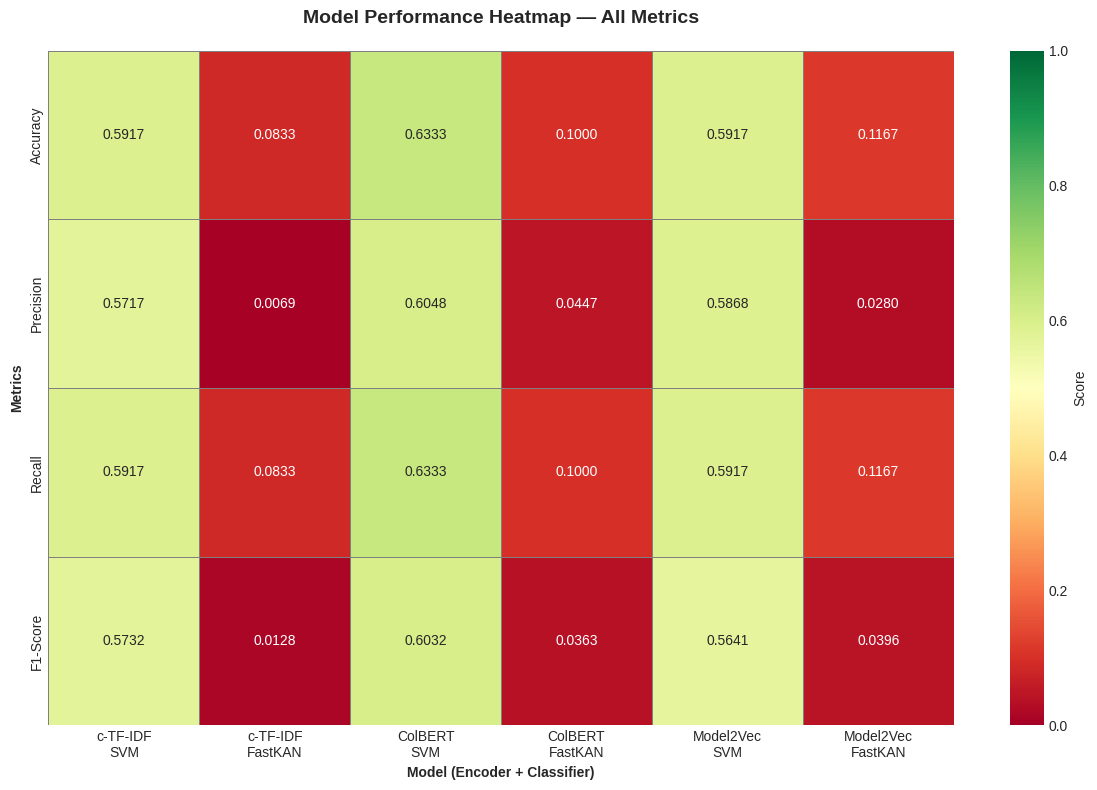

✓ Saved heatmap_all_metrics.png



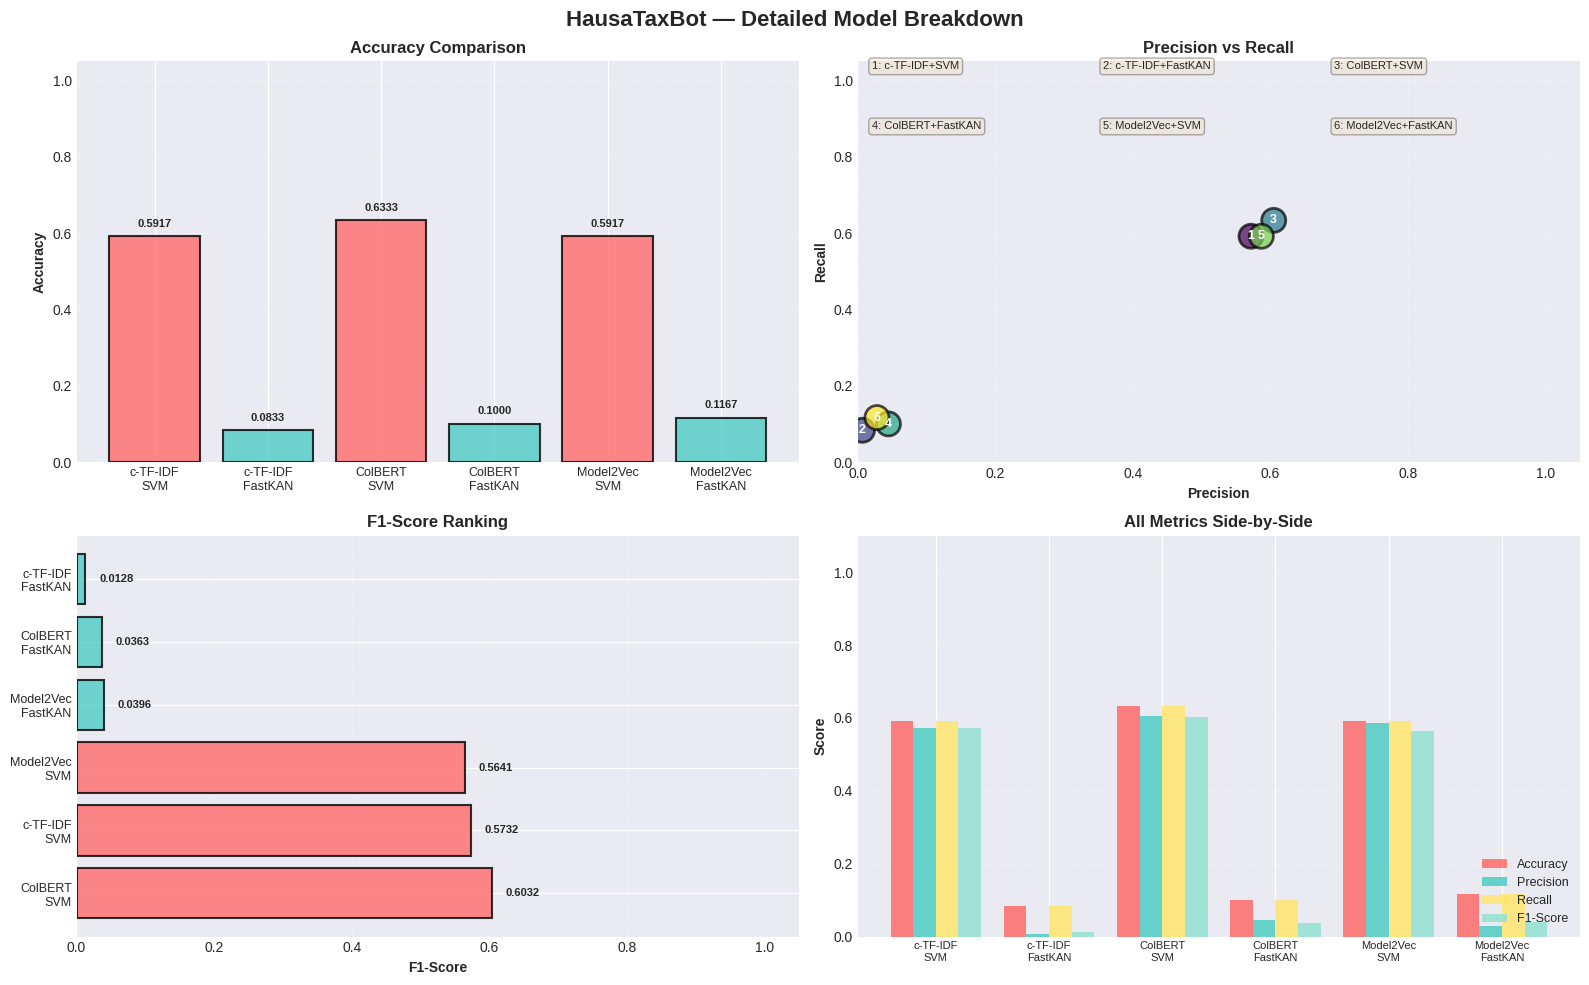

✓ Saved detailed_comparison.png



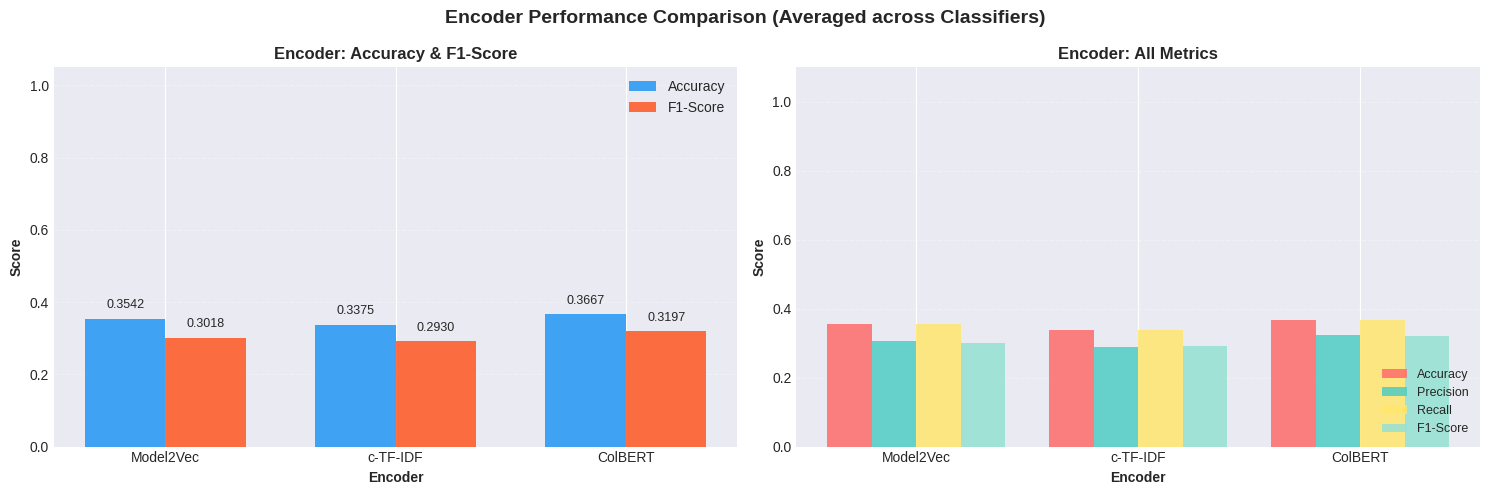

✓ Saved encoder_comparison.png



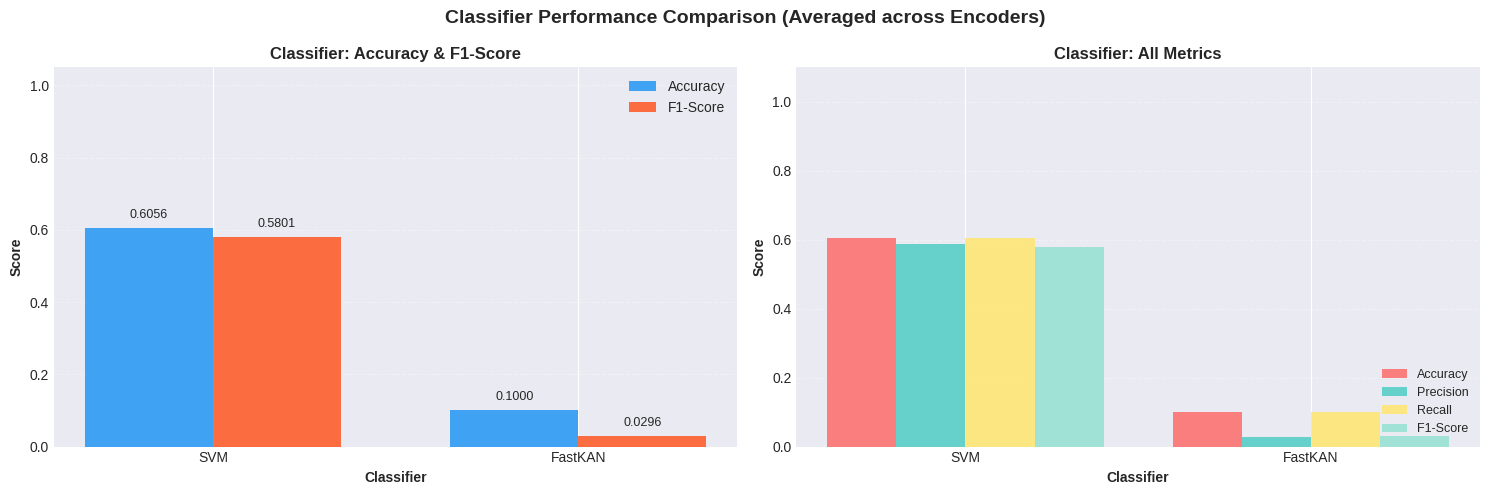

✓ Saved classifier_comparison.png



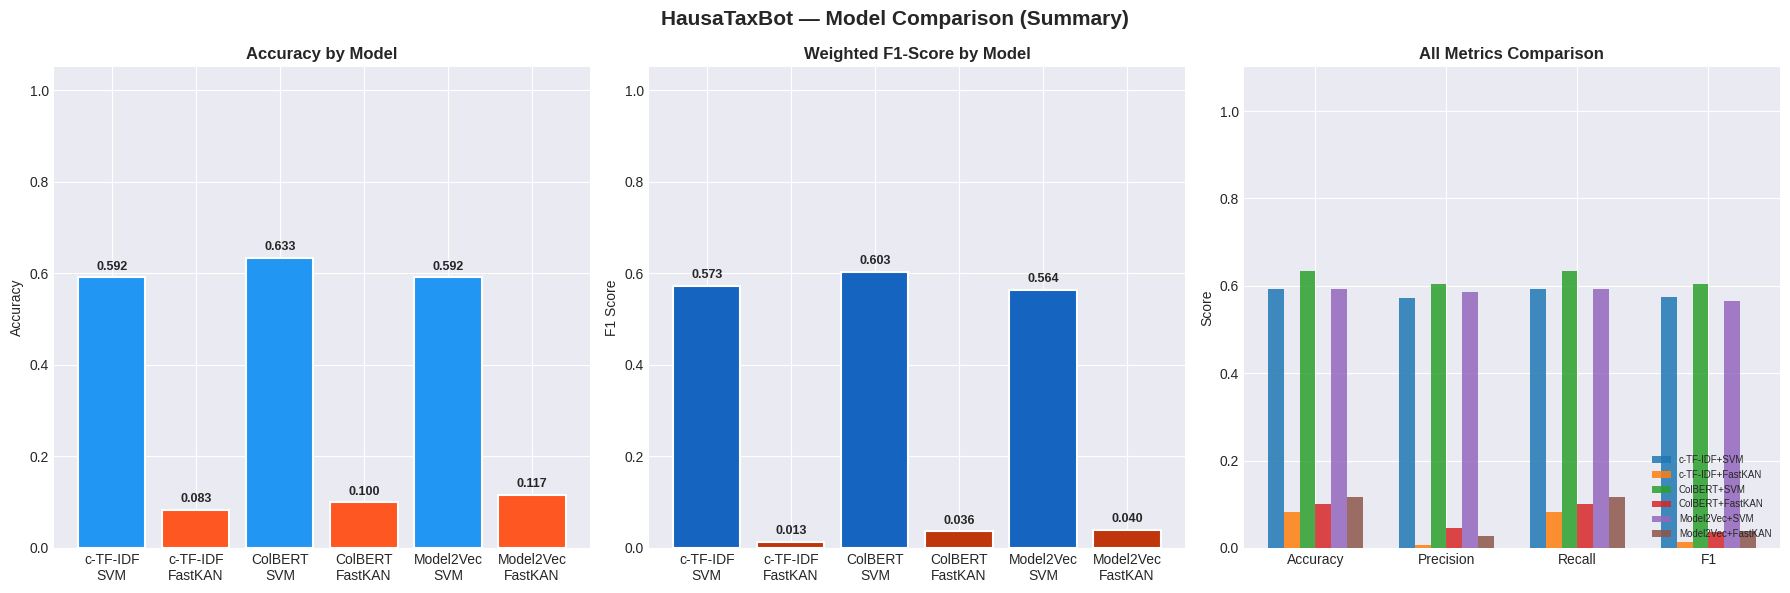

✓ Saved evaluation_comparison.png



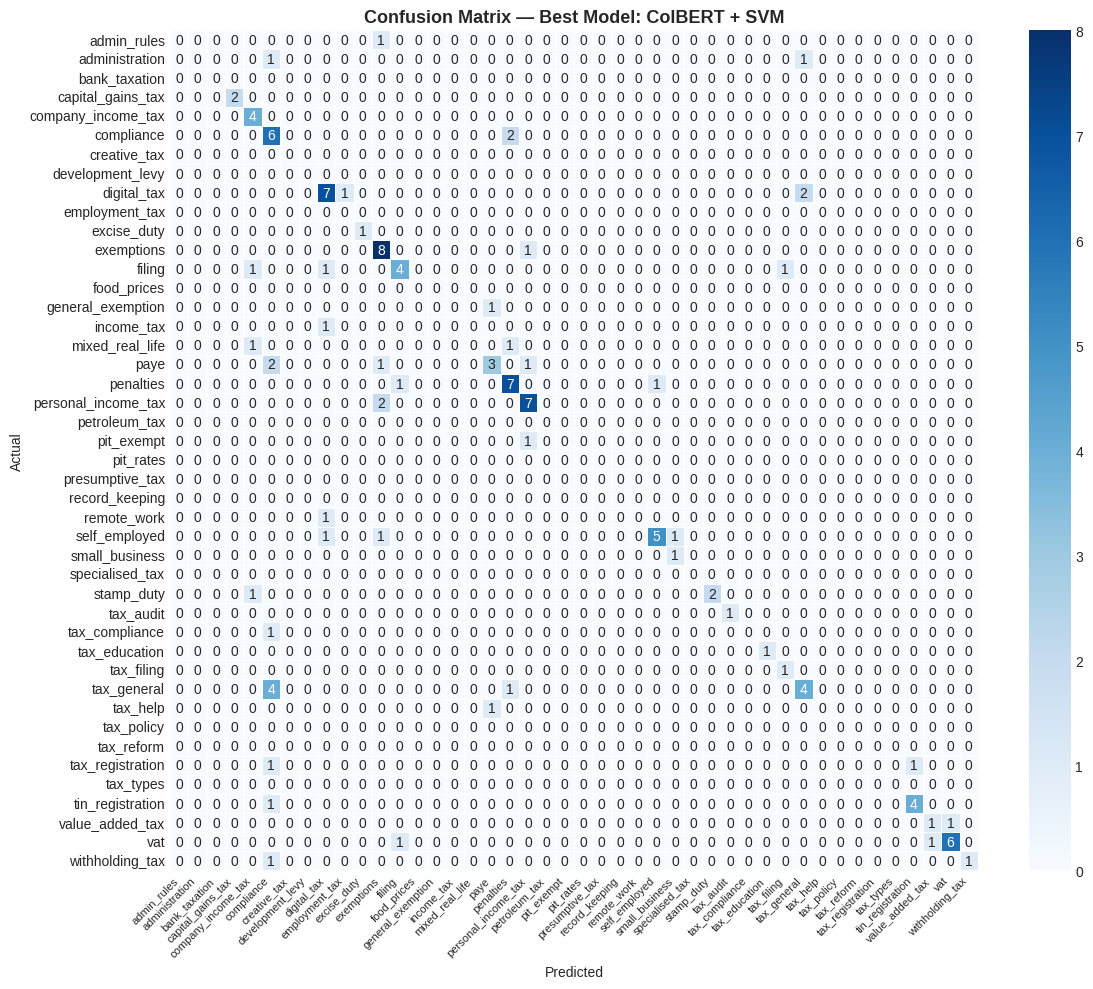

✓ Saved confusion_matrix.png

✓ ALL VISUALIZATIONS GENERATED SUCCESSFULLY


In [8]:
# Cell 7 - Comprehensive Visualisations
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# ════════════════════════════════════════════════════════════════════════════
# VISUALIZATION 1: Full metric heatmap
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 8))

metrics_data = []
model_names_heat = []
for r in results:
    model_names_heat.append(f"{r['encoder']}\n{r['classifier']}")
    metrics_data.append([r['accuracy'], r['precision'], r['recall'], r['f1']])

metrics_data = np.array(metrics_data)
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

sns.heatmap(metrics_data.T, annot=True, fmt='.4f', cmap='RdYlGn', 
            xticklabels=model_names_heat, yticklabels=metrics_cols,
            cbar_kws={'label': 'Score'}, ax=ax, vmin=0, vmax=1,
            linewidths=0.5, linecolor='gray', annot_kws={'fontsize': 10})
ax.set_title('Model Performance Heatmap — All Metrics', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Model (Encoder + Classifier)', fontweight='bold')
ax.set_ylabel('Metrics', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved heatmap_all_metrics.png\n")

# ════════════════════════════════════════════════════════════════════════════
# VISUALIZATION 2: Encoder vs Classifier breakdown
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('HausaTaxBot — Detailed Model Breakdown', fontsize=16, fontweight='bold')

enc_names  = [r['encoder'] for r in results]
clf_names  = [r['classifier'] for r in results]
accs       = [r['accuracy'] for r in results]
precs      = [r['precision'] for r in results]
recs       = [r['recall'] for r in results]
f1s        = [r['f1'] for r in results]
names      = [f"{e}\n{c}" for e, c in zip(enc_names, clf_names)]

colors_enc = ['#FF6B6B' if c == 'SVM' else '#4ECDC4' for c in clf_names]

# Plot 1: Accuracy comparison
ax = axes[0, 0]
bars = ax.bar(range(len(names)), accs, color=colors_enc, edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_title('Accuracy Comparison', fontweight='bold', fontsize=12)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy', fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 2: Precision vs Recall scatter
ax = axes[0, 1]
scatter = ax.scatter(precs, recs, s=300, c=range(len(results)), cmap='viridis', 
                    alpha=0.7, edgecolors='black', linewidth=2)
for i, name in enumerate(names):
    ax.annotate(f"{i+1}", (precs[i], recs[i]), ha='center', va='center', 
               fontweight='bold', fontsize=9, color='white')
ax.set_xlabel('Precision', fontweight='bold')
ax.set_ylabel('Recall', fontweight='bold')
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3, linestyle='--')
ax.set_title('Precision vs Recall', fontweight='bold', fontsize=12)
for i, name in enumerate(['1: c-TF-IDF+SVM', '2: c-TF-IDF+FastKAN', 
                          '3: ColBERT+SVM', '4: ColBERT+FastKAN',
                          '5: Model2Vec+SVM', '6: Model2Vec+FastKAN']):
    ax.text(0.02 + (i%3)*0.32, 0.98 - (i//3)*0.15, name, 
           transform=ax.transAxes, fontsize=8, bbox=dict(boxstyle='round', 
           facecolor='wheat', alpha=0.3))

# Plot 3: F1-Score ranking
ax = axes[1, 0]
sorted_idx = np.argsort(f1s)[::-1]
sorted_names = [names[i] for i in sorted_idx]
sorted_f1s = [f1s[i] for i in sorted_idx]
colors_ranked = [colors_enc[i] for i in sorted_idx]
bars = ax.barh(range(len(sorted_names)), sorted_f1s, color=colors_ranked, 
              edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('F1-Score', fontweight='bold')
ax.set_xlim(0, 1.05)
ax.set_title('F1-Score Ranking', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3, linestyle='--')
for i, (bar, val) in enumerate(zip(bars, sorted_f1s)):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
           f'{val:.4f}', ha='left', va='center', fontsize=8, fontweight='bold')

# Plot 4: All metrics grouped by model
ax = axes[1, 1]
x = np.arange(len(names))
width = 0.2
ax.bar(x - 1.5*width, accs, width, label='Accuracy', alpha=0.85, color='#FF6B6B')
ax.bar(x - 0.5*width, precs, width, label='Precision', alpha=0.85, color='#4ECDC4')
ax.bar(x + 0.5*width, recs, width, label='Recall', alpha=0.85, color='#FFE66D')
ax.bar(x + 1.5*width, f1s, width, label='F1-Score', alpha=0.85, color='#95E1D3')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel('Score', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('All Metrics Side-by-Side', fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('detailed_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved detailed_comparison.png\n")

# ════════════════════════════════════════════════════════════════════════════
# VISUALIZATION 3: Encoder comparison (average performance)
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Encoder Performance Comparison (Averaged across Classifiers)', 
            fontsize=14, fontweight='bold')

encoder_metrics = {}
for enc in set(enc_names):
    enc_results = [r for r in results if r['encoder'] == enc]
    encoder_metrics[enc] = {
        'accuracy': np.mean([r['accuracy'] for r in enc_results]),
        'precision': np.mean([r['precision'] for r in enc_results]),
        'recall': np.mean([r['recall'] for r in enc_results]),
        'f1': np.mean([r['f1'] for r in enc_results])
    }

# Plot 1: Encoder accuracy and F1
ax = axes[0]
enc_list = list(encoder_metrics.keys())
enc_accs = [encoder_metrics[e]['accuracy'] for e in enc_list]
enc_f1s = [encoder_metrics[e]['f1'] for e in enc_list]
x_pos = np.arange(len(enc_list))
width = 0.35
ax.bar(x_pos - width/2, enc_accs, width, label='Accuracy', alpha=0.85, color='#2196F3')
ax.bar(x_pos + width/2, enc_f1s, width, label='F1-Score', alpha=0.85, color='#FF5722')
ax.set_xlabel('Encoder', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Encoder: Accuracy & F1-Score', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(enc_list, fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
for i, (acc, f1) in enumerate(zip(enc_accs, enc_f1s)):
    ax.text(i - width/2, acc + 0.02, f'{acc:.4f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, f1 + 0.02, f'{f1:.4f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Encoder all metrics
ax = axes[1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(enc_list))
width = 0.2
colors_bar = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3']
for i, metric in enumerate(['accuracy', 'precision', 'recall', 'f1']):
    values = [encoder_metrics[e][metric] for e in enc_list]
    ax.bar(x_pos + (i - 1.5)*width, values, width, label=metrics_names[i], 
          alpha=0.85, color=colors_bar[i])
ax.set_xlabel('Encoder', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Encoder: All Metrics', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(enc_list, fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('encoder_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved encoder_comparison.png\n")

# ════════════════════════════════════════════════════════════════════════════
# VISUALIZATION 4: Classifier comparison (average performance)
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Classifier Performance Comparison (Averaged across Encoders)', 
            fontsize=14, fontweight='bold')

classifier_metrics = {}
for clf in set(clf_names):
    clf_results = [r for r in results if r['classifier'] == clf]
    classifier_metrics[clf] = {
        'accuracy': np.mean([r['accuracy'] for r in clf_results]),
        'precision': np.mean([r['precision'] for r in clf_results]),
        'recall': np.mean([r['recall'] for r in clf_results]),
        'f1': np.mean([r['f1'] for r in clf_results])
    }

# Plot 1: Classifier accuracy and F1
ax = axes[0]
clf_list = list(classifier_metrics.keys())
clf_accs = [classifier_metrics[c]['accuracy'] for c in clf_list]
clf_f1s = [classifier_metrics[c]['f1'] for c in clf_list]
x_pos = np.arange(len(clf_list))
width = 0.35
ax.bar(x_pos - width/2, clf_accs, width, label='Accuracy', alpha=0.85, color='#2196F3')
ax.bar(x_pos + width/2, clf_f1s, width, label='F1-Score', alpha=0.85, color='#FF5722')
ax.set_xlabel('Classifier', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Classifier: Accuracy & F1-Score', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(clf_list, fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
for i, (acc, f1) in enumerate(zip(clf_accs, clf_f1s)):
    ax.text(i - width/2, acc + 0.02, f'{acc:.4f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, f1 + 0.02, f'{f1:.4f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Classifier all metrics
ax = axes[1]
x_pos = np.arange(len(clf_list))
width = 0.2
for i, metric in enumerate(['accuracy', 'precision', 'recall', 'f1']):
    values = [classifier_metrics[c][metric] for c in clf_list]
    ax.bar(x_pos + (i - 1.5)*width, values, width, label=metrics_names[i], 
          alpha=0.85, color=colors_bar[i])
ax.set_xlabel('Classifier', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Classifier: All Metrics', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(clf_list, fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved classifier_comparison.png\n")

# ════════════════════════════════════════════════════════════════════════════
# VISUALIZATION 5: Original comparison plots
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('HausaTaxBot — Model Comparison (Summary)', fontsize=15, fontweight='bold')

colors_acc = ['#2196F3' if c == 'SVM' else '#FF5722' for c in clf_names]
colors_f1  = ['#1565C0' if c == 'SVM' else '#BF360C' for c in clf_names]

# Plot 1: Accuracy
ax = axes[0]
bars = ax.bar(names, accs, color=colors_acc, edgecolor='white', linewidth=1.5)
ax.set_title('Accuracy by Model', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: F1-Score
ax = axes[1]
bars = ax.bar(names, f1s, color=colors_f1, edgecolor='white', linewidth=1.5)
ax.set_title('Weighted F1-Score by Model', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Grouped comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x     = np.arange(len(metrics))
width = 0.12
ax    = axes[2]
for i, r in enumerate(results):
    vals = [r['accuracy'], r['precision'], r['recall'], r['f1']]
    offset = (i - len(results)/2) * width + width/2
    ax.bar(x + offset, vals, width,
           label=f"{r['encoder']}+{r['classifier']}", alpha=0.85)
ax.set_title('All Metrics Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved evaluation_comparison.png\n")

# ── Confusion matrix for best model ──────────────────────────
best = max(results, key=lambda x: x['f1'])
cm = confusion_matrix(y_test_str, best['preds'],
                        labels=list(le.classes_))
fig2, ax2 = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax2, linewidths=0.5)
ax2.set_title(f"Confusion Matrix — Best Model: {best['encoder']} + {best['classifier']}",
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved confusion_matrix.png")

print("\n" + "="*70)
print("✓ ALL VISUALIZATIONS GENERATED SUCCESSFULLY")
print("="*70)

In [9]:
# Cell 8 - Per-Class Classification Report
best = max(results, key=lambda x: x['f1'])
print(f"Best model: {best['encoder']} + {best['classifier']}")
print(f"Accuracy: {best['accuracy']:.4f}  |  F1: {best['f1']:.4f}\n")
print(classification_report(y_test_str, best['preds'],
                             zero_division=0, digits=4))


Best model: ColBERT + SVM
Accuracy: 0.6333  |  F1: 0.6032

                     precision    recall  f1-score   support

        admin_rules     0.0000    0.0000    0.0000         1
     administration     0.0000    0.0000    0.0000         2
  capital_gains_tax     1.0000    1.0000    1.0000         2
 company_income_tax     0.5714    1.0000    0.7273         4
         compliance     0.3529    0.7500    0.4800         8
        digital_tax     0.6364    0.7000    0.6667        10
     employment_tax     0.0000    0.0000    0.0000         0
        excise_duty     1.0000    1.0000    1.0000         1
         exemptions     0.6154    0.8889    0.7273         9
             filing     0.6667    0.5714    0.6154         7
  general_exemption     0.0000    0.0000    0.0000         1
         income_tax     0.0000    0.0000    0.0000         1
    mixed_real_life     0.0000    0.0000    0.0000         2
               paye     0.6000    0.4286    0.5000         7
          penalties     0

In [10]:
# Cell 9 - Train & Save ALL Model Pairs (Encoder+Classifier Combinations)
# This ensures frontend can load any encoder+classifier without dimensional mismatches
import os
os.makedirs('models', exist_ok=True)
os.makedirs('evaluation', exist_ok=True)

# Save baseline results
with open('evaluation/results.json', 'w', encoding='utf-8') as f:
    safe_results = [{k: v for k, v in r.items() if k != 'preds'}
                    for r in results]
    json.dump({'results': safe_results,
               'best_model': f"{best['encoder']} + {best['classifier']}",
               'best_accuracy': best['accuracy'],
               'best_f1': best['f1'],
               'n_classes': len(le.classes_),
               'n_samples_train': len(X_train),
               'n_samples_test': len(X_test),
               'timestamp': datetime.now().isoformat()},
              f, indent=2)
print("✓ Saved evaluation/results.json")

print("\n" + "="*70)
print("TRAINING ALL ENCODER + CLASSIFIER COMBINATIONS AS MODEL PAIRS")
print("="*70 + "\n")

# Prepare full training data (train + val)
X_full = X_train + X_val
y_full = np.concatenate([y_train_str, y_val_str])

# Define all encoder and classifier variants
encoder_configs = {
    'ctfidf': {'class': CTFIDFEncoder, 'params': {'n_features': 8000}},
    'colbert': {'class': ColBERTEncoder, 'params': {'n_components': 256}},
    'model2vec': {'class': Model2VecEncoder, 'params': {'n_components': 256}}
}

classifier_configs = {
    'svm': {'class': SVMClassifier, 'params': {'C': 5.0}},
    'fastkan': {'class': FastKANClassifier, 'params': {'hidden_dim': 128, 'grid_size': 8, 'n_epochs': 100}}
}

# Store metadata about all trained pairs
model_pairs_metadata = []

# Train and save all combinations
print("Training all encoder+classifier pairs on full training data (train+val):\n")

for enc_name, enc_config in encoder_configs.items():
    print(f"  [{enc_name.upper()}]")
    
    # Train encoder
    enc_instance = enc_config['class'](**enc_config['params'])
    if enc_name == 'ctfidf':
        enc_instance.fit(X_full, y_full)
    else:
        enc_instance.fit(X_full)
    
    # Encode full data
    X_full_encoded = enc_instance.encode(X_full)
    print(f"    Encoded shape: {X_full_encoded.shape}")
    
    # Train both classifiers on this encoder's output
    for clf_name, clf_config in classifier_configs.items():
        print(f"    ↳ Training {clf_name.upper()}...", end=' ')
        
        # Create and train classifier
        clf_instance = clf_config['class'](**clf_config['params'])
        clf_instance.fit(X_full_encoded, y_full, encoder_name=enc_name.upper())
        
        # Create combined model (encoder + classifier pair)
        model_pair = {
            'encoder': enc_instance,
            'classifier': clf_instance,
            'encoder_name': enc_name,
            'classifier_name': clf_name
        }
        
        # Save as pickle
        pair_name = f"{enc_name}_{clf_name}"
        model_path = f"models/{pair_name}.pkl"
        with open(model_path, 'wb') as f:
            pickle.dump(model_pair, f)
        
        print(f"✓ Saved to models/{pair_name}.pkl")
        
        # Add to metadata list
        model_pairs_metadata.append({
            'pair_name': pair_name,
            'encoder': enc_name,
            'classifier': clf_name,
            'file': model_path,
            'display_name': f"{enc_name.upper()} + {clf_name.upper()}"
        })

print("\n" + "="*70)
print(f"✓ Saved {len(model_pairs_metadata)} model pairs to /models/")
print("="*70 + "\n")

# Save model pairs metadata for frontend
with open('models/available_models.json', 'w', encoding='utf-8') as f:
    json.dump({
        'available_pairs': model_pairs_metadata,
        'best_pair': {
            'encoder': best['encoder'].lower().replace('-', '').replace(' ', ''),
            'classifier': best['classifier'].lower(),
            'accuracy': float(best['accuracy']),
            'f1': float(best['f1'])
        },
        'timestamp': datetime.now().isoformat()
    }, f, indent=2)

print("✓ Saved models/available_models.json (frontend config)")

# Also maintain backward compatibility: save best model as "deploy" pair
print(f"\nMaintaining backward compatibility...")
best_enc_name = best['encoder'].lower().replace('-', '').replace(' ', '')
best_clf_name = best['classifier'].lower()
best_pair_name = f"{best_enc_name}_{best_clf_name}"

best_pair = {
    'encoder': encoder_configs[best_enc_name]['class'](**encoder_configs[best_enc_name]['params']),
    'classifier': classifier_configs[best_clf_name]['class'](**classifier_configs[best_clf_name]['params'])
}

if best_enc_name == 'ctfidf':
    best_pair['encoder'].fit(X_full, y_full)
else:
    best_pair['encoder'].fit(X_full)

X_full_best = best_pair['encoder'].encode(X_full)
best_pair['classifier'].fit(X_full_best, y_full, encoder_name=best['encoder'])

# Save for backward compatibility
with open('evaluation/deploy_encoder.pkl', 'wb') as f:
    pickle.dump(best_pair['encoder'], f)
with open('evaluation/deploy_classifier.pkl', 'wb') as f:
    pickle.dump(best_pair['classifier'], f)

print(f"✓ Saved evaluation/deploy_encoder.pkl (best pair: {best_pair_name})")
print(f"✓ Saved evaluation/deploy_classifier.pkl (best pair: {best_pair_name})")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Best model: {best['encoder']} + {best['classifier']}")
print(f"Best Accuracy: {best['accuracy']:.4f}  |  F1: {best['f1']:.4f}")
print(f"\nAll model pairs available in: /models/")
print(f"Frontend config: models/available_models.json")
print(f"Backward compatible deploy models: evaluation/deploy_*.pkl")
print("="*70 + "\n")

✓ Saved evaluation/results.json

TRAINING ALL ENCODER + CLASSIFIER COMBINATIONS AS MODEL PAIRS

Training all encoder+classifier pairs on full training data (train+val):

  [CTFIDF]


    Encoded shape: (676, 4184)
    ↳ Training SVM... ✓ Saved to models/ctfidf_svm.pkl
    ↳ Training FASTKAN... ✓ Saved to models/ctfidf_fastkan.pkl
  [COLBERT]
    ColBERT SVD explains 77.6% variance (dim=256)
    Encoded shape: (676, 256)
    ↳ Training SVM... ✓ Saved to models/colbert_svm.pkl
    ↳ Training FASTKAN... ✓ Saved to models/colbert_fastkan.pkl
  [MODEL2VEC]
    Model2Vec: captured 69.8% energy (d=256)
    Encoded shape: (676, 256)
    ↳ Training SVM... ✓ Saved to models/model2vec_svm.pkl
    ↳ Training FASTKAN... ✓ Saved to models/model2vec_fastkan.pkl

✓ Saved 6 model pairs to /models/

✓ Saved models/available_models.json (frontend config)

Maintaining backward compatibility...
    ColBERT SVD explains 77.6% variance (dim=256)
✓ Saved evaluation/deploy_encoder.pkl (best pair: colbert_svm)
✓ Saved evaluation/deploy_classifier.pkl (best pair: colbert_svm)

SUMMARY
Best model: ColBERT + SVM
Best Accuracy: 0.6333  |  F1: 0.6032

All model pairs available in: /models/
Front

In [11]:
# Cell 10 - Retrieval-Based Chatbot Function
# Build full-corpus TF-IDF index on ALL 898 records for retrieval

from sklearn.metrics.pairwise import cosine_similarity

# Build retrieval index on full corpus
retrieval_tfidf = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True,
                                   min_df=1, analyzer='word')
all_texts   = [build_text(r) for r in corpus]
corpus_mat  = retrieval_tfidf.fit_transform(all_texts)

def chat(user_query: str, top_k: int = 3) -> str:
    """
    Retrieval-based chatbot:
    1. Encode the user query with the full-corpus TF-IDF
    2. Find top-k most similar Q&A pairs
    3. Return best matching answer + confidence
    """
    q_vec  = retrieval_tfidf.transform([user_query])
    sims   = cosine_similarity(q_vec, corpus_mat).flatten()
    top_idx = sims.argsort()[::-1][:top_k]

    best_idx  = top_idx[0]
    best_sim  = sims[best_idx]
    best_rec  = corpus[best_idx]

    confidence = "HIGH" if best_sim >= 0.5 else ("MEDIUM" if best_sim >= 0.25 else "LOW")

    response  = f"**Intent:** {best_rec['intent'].replace('_',' ').title()}\n"
    response += f"**Amsa (Answer):**\n{best_rec['answer']}\n\n"
    response += f"**Tushe (Source):** {best_rec['source']}\n"
    response += f"---\n*Kamancen: {best_sim:.2%} ({confidence})*"
    return response

# Quick smoke test
test_q = "Menene harajin VAT?"
print(f"Test query: '{test_q}'")
print()
print(chat(test_q))


Test query: 'Menene harajin VAT?'

**Intent:** Value Added Tax
**Amsa (Answer):**
VAT haraji ne da ake ƙara wa kayayyaki da ayyuka a lokacin saye da sayarwa.

**Tushe (Source):** FIRS Tax Law Compendium, Fourth Schedule
---
*Kamancen: 36.24% (MEDIUM)*


In [12]:
# NEW: Top-K retrieval + cosine-based reranker
from sklearn.metrics.pairwise import cosine_similarity

def rerank_retrieval(query, encoder, classifier, qa_data, top_k=3, alpha=0.5, conf_thresh=0.25):
    """Return reranked top candidate Q&A pairs using classifier + cosine fusion.

    Returns list of tuples: (pair, combined_score, similarity, classifier_prob)
    """
    # Encode query
    if hasattr(encoder, 'transform'):
        q_vec = np.asarray(encoder.transform([query]))
    else:
        q_vec = np.asarray(encoder.encode([query]))

    # Get classifier probs if available
    probs = None
    try:
        if hasattr(classifier, 'predict_proba'):
            probs = classifier.predict_proba(q_vec)[0]
    except Exception:
        probs = None

    candidate_pairs = []
    if probs is not None and hasattr(classifier, 'classes_'):
        top_idxs = np.argsort(probs)[::-1][:top_k]
        for idx in top_idxs:
            label = classifier.classes_[idx]
            p = float(probs[idx])
            for pair in qa_data['qa_pairs']:
                if str(pair.get('intent', '')).strip() == str(label).strip():
                    candidate_pairs.append((pair, p))
    else:
        # fallback: use classifier.predict
        try:
            pred = classifier.predict(q_vec)[0]
            p = 0.6
            for pair in qa_data['qa_pairs']:
                if str(pair.get('intent','')).strip() == str(pred).strip():
                    candidate_pairs.append((pair, p))
        except Exception:
            candidate_pairs = []

    if not candidate_pairs:
        return []

    # Encode candidate questions
    questions = [p[0].get('question','') for p in candidate_pairs]
    if hasattr(encoder, 'transform'):
        q_emb = np.asarray(encoder.transform(questions))
    else:
        q_emb = np.asarray(encoder.encode(questions))

    # normalize
    def _norm(a):
        a = np.asarray(a, dtype=np.float32)
        norms = np.linalg.norm(a, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return a / norms

    qe = _norm(q_vec)[0]
    qn = _norm(q_emb)
    sims = (qn @ qe).reshape(-1)

    results = []
    for i, (pair, cls_prob) in enumerate(candidate_pairs):
        sim = float(sims[i]) if i < len(sims) else 0.0
        score = alpha * float(cls_prob) + (1 - alpha) * max(0.0, sim)
        results.append((pair, float(score), float(sim), float(cls_prob)))

    results.sort(key=lambda x: x[1], reverse=True)
    return results


# Example usage (if variables exist in the notebook environment)
try:
    sample_q = test_q if 'test_q' in globals() else 'Yaya zan yi rajista TIN?'
    print('Query:', sample_q)
    top_candidates = rerank_retrieval(sample_q, enc_instance, svm if 'svm' in globals() else svm, corpus and svm)
    if top_candidates:
        for i, (pair, score, sim, p) in enumerate(top_candidates[:5], 1):
            print(f"\n{i}. Question: {pair.get('question','')}")
            print(f"   Answer: {pair.get('answer','')[:160]}")
            print(f"   Combined score={score:.4f} | sim={sim:.4f} | cls_prob={p:.4f}")
    else:
        print('No candidates found for reranking.')
except Exception as e:
    print('Example rerank not executed (not all variables present):', e)


Query: Menene harajin VAT?
No candidates found for reranking.
